In [ ]:
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

# Зашумить изображение при помощи шума гаусса, постоянного шума.

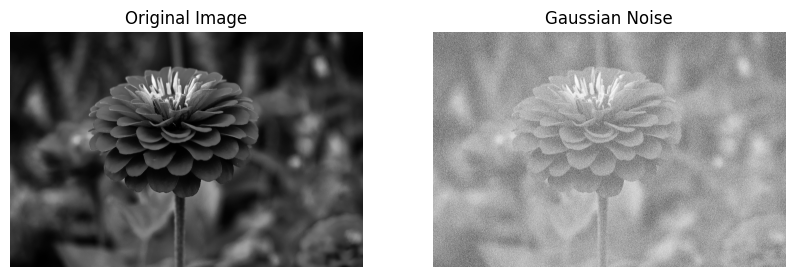

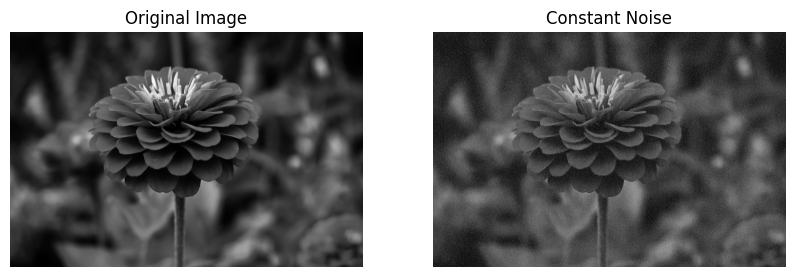

In [13]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Добавление гауссовского шума
gaussian_noise = np.random.normal(0, 25, image_gray.shape).astype(np.uint8)
noisy_image_gaussian = cv2.add(image_gray, gaussian_noise)
plt.subplot(1, 2, 2)
plt.imshow(noisy_image_gaussian, cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')
plt.show()

# Добавление постоянного шума (Salt and Pepper)
noisy_image_constant = image_gray.copy()
ammount = 0.2 
num_salt = np.ceil(ammount * image_gray.size * 0.5).astype(int)
num_pepper = np.ceil(ammount * image_gray.size * 0.5).astype(int)

np.random.seed(1991)

salt_coords = np.random.choice(image_gray.size, size=num_salt, replace=False)
pepper_coords = np.random.choice(image_gray.size, size=num_pepper, replace=False)
noisy_image_constant.flat[salt_coords] = 255
noisy_image_constant.flat[pepper_coords] = 0
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(noisy_image_constant, cmap='gray')
plt.title('Constant Noise')
plt.axis('off')
plt.show()

# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [ ]:
# Медианный фильтр
median_filtered_gaussian1 = cv2.medianBlur(noisy_image_gaussian, 5) # 5 - размер ядра, который определяет, сколько соседних пикселей будет использоваться для вычисления медианы
median_filtered_gaussian2 = cv2.medianBlur(noisy_image_gaussian, 7)
median_filtered_gaussian3 = cv2.medianBlur(noisy_image_gaussian, 9)
median_filtered_constant1 = cv2.medianBlur(noisy_image_constant, 5)
median_filtered_constant2 = cv2.medianBlur(noisy_image_constant, 7)
median_filtered_constant3 = cv2.medianBlur(noisy_image_constant, 9)

# Фильтр Гаусса
gaussian_filtered_gaussian1 = cv2.GaussianBlur(noisy_image_gaussian, (5, 5), 0) # sigma=0 означает, что стандартное отклонение будет вычислено на основе размера ядра
gaussian_filtered_gaussian2 = cv2.GaussianBlur(noisy_image_gaussian, (7, 7), 0)
gaussian_filtered_gaussian3 = cv2.GaussianBlur(noisy_image_gaussian, (9, 9), 0)
gaussian_filtered_constant1 = cv2.GaussianBlur(noisy_image_constant, (5, 5), 0)
gaussian_filtered_constant2 = cv2.GaussianBlur(noisy_image_constant, (7, 7), 0)
gaussian_filtered_constant3 = cv2.GaussianBlur(noisy_image_constant, (9, 9), 0)

# Билатеральный фильтр
bilateral_filtered_gaussian1 = cv2.bilateralFilter(noisy_image_gaussian, 9, 75, 75) # 9 - размер ядра, 75 - sigmaColor, 75 - sigmaSpace
bilateral_filtered_gaussian2 = cv2.bilateralFilter(noisy_image_gaussian, 11, 75, 75)
bilateral_filtered_gaussian3 = cv2.bilateralFilter(noisy_image_gaussian, 13, 75, 75)
bilateral_filtered_constant1 = cv2.bilateralFilter(noisy_image_constant, 9, 75, 75)
bilateral_filtered_constant2 = cv2.bilateralFilter(noisy_image_constant, 11, 75, 75)
bilateral_filtered_constant3 = cv2.bilateralFilter(noisy_image_constant, 13, 75, 75)

# Фильтр нелокальных средних
nlm_filtered_gaussian1 = cv2.fastNlMeansDenoising(noisy_image_gaussian, None, 30, 7, 21) # 30 - h (параметр фильтрации), 7 - templateWindowSize (размер шаблона), 21 - searchWindowSize (размер окна поиска)
nlm_filtered_gaussian2 = cv2.fastNlMeansDenoising(noisy_image_gaussian, None, 40, 7, 21)
nlm_filtered_gaussian3 = cv2.fastNlMeansDenoising(noisy_image_gaussian, None, 50, 7, 21)
nlm_filtered_constant1 = cv2.fastNlMeansDenoising(noisy_image_constant, None, 30, 7, 21)
nlm_filtered_constant2 = cv2.fastNlMeansDenoising(noisy_image_constant, None, 40, 7, 21)
nlm_filtered_constant3 = cv2.fastNlMeansDenoising(noisy_image_constant, None, 50, 7, 21)

# Оценка качества фильтрации
def evaluate_filter(original, filtered):
    mse = mean_squared_error(original, filtered)
    ssim_value = ssim(original, filtered)
    return mse, ssim_value

filters = {
    'Median Filter (Gaussian Noise)': [(median_filtered_gaussian1, 5), (median_filtered_gaussian2, 7), (median_filtered_gaussian3, 9)],
    'Median Filter (Constant Noise)': [(median_filtered_constant1, 5), (median_filtered_constant2, 7), (median_filtered_constant3, 9)],
    'Gaussian Filter (Gaussian Noise)': [(gaussian_filtered_gaussian1, '5x5'), (gaussian_filtered_gaussian2, '7x7'), (gaussian_filtered_gaussian3, '9x9')],
    'Gaussian Filter (Constant Noise)': [(gaussian_filtered_constant1, '5x5'), (gaussian_filtered_constant2, '7x7'), (gaussian_filtered_constant3, '9x9')],
    'Bilateral Filter (Gaussian Noise)': [(bilateral_filtered_gaussian1, 9), (bilateral_filtered_gaussian2, 11), (bilateral_filtered_gaussian3, 13)],
    'Bilateral Filter (Constant Noise)': [(bilateral_filtered_constant1, 9), (bilateral_filtered_constant2, 11), (bilateral_filtered_constant3, 13)],
    'NLM Filter (Gaussian Noise)': [(nlm_filtered_gaussian1, 30), (nlm_filtered_gaussian2, 40), (nlm_filtered_gaussian3, 50)],
    'NLM Filter (Constant Noise)': [(nlm_filtered_constant1, 30), (nlm_filtered_constant2, 40), (nlm_filtered_constant3, 50)]
}

results = {}
for filter_name, filtered_data in filters.items():
    results[filter_name] = []
    for filtered_image, param in filtered_data:
        mse, ssim_value = evaluate_filter(image_gray, filtered_image)
        results[filter_name].append((mse, ssim_value, param))

# Вывод результатов
for filter_name, metrics in results.items():
    print(f"{filter_name}:")
    for mse, ssim_value, param in metrics:
        print(f"  Parameter {param}: MSE={mse:.2f}, SSIM={ssim_value:.4f}")


Median Filter (Gaussian Noise):
  Parameter 5: MSE=17367.29, SSIM=0.0167
  Parameter 7: MSE=16357.76, SSIM=0.0379
  Parameter 9: MSE=15406.59, SSIM=0.0684
Median Filter (Constant Noise):
  Parameter 5: MSE=12.57, SSIM=0.8531
  Parameter 7: MSE=12.46, SSIM=0.8530
  Parameter 9: MSE=12.46, SSIM=0.8532
Gaussian Filter (Gaussian Noise):
  Parameter 5x5: MSE=11899.69, SSIM=0.0855
  Parameter 7x7: MSE=11613.92, SSIM=0.1488
  Parameter 9x9: MSE=11512.77, SSIM=0.1980
Gaussian Filter (Constant Noise):
  Parameter 5x5: MSE=493.64, SSIM=0.2268
  Parameter 7x7: MSE=360.74, SSIM=0.3549
  Parameter 9x9: MSE=313.67, SSIM=0.4411
Bilateral Filter (Gaussian Noise):
  Parameter 9: MSE=17823.44, SSIM=0.0162
  Parameter 11: MSE=17811.76, SSIM=0.0164
  Parameter 13: MSE=17806.70, SSIM=0.0165
Bilateral Filter (Constant Noise):
  Parameter 9: MSE=2630.07, SSIM=0.0577
  Parameter 11: MSE=2596.27, SSIM=0.0581
  Parameter 13: MSE=2582.59, SSIM=0.0577
NLM Filter (Gaussian Noise):
  Parameter 30: MSE=19530.15, SSI

# Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [20]:
# Найти лучший фильтр для гауссовского шума по MSE
best_filter = None
best_mse = float('inf')

for filter_name, metrics in results.items():
    if 'Gaussian Noise' in filter_name:
        for mse, ssim_value, param in metrics:
            if mse < best_mse:
                best_mse = mse
                best_filter = (filter_name, param, mse, ssim_value)

print(f"Лучший фильтр для гауссовского шума по MSE:")
print(f"  Фильтр: {best_filter[0]}")
print(f"  Параметр: {best_filter[1]}")
print(f"  MSE: {best_filter[2]:.2f}")
print(f"  SSIM: {best_filter[3]:.4f}")

# Найти лучший фильтр для постоянного шума по MSE
best_filter_constant = None
best_mse_constant = float('inf')

for filter_name, metrics in results.items():
    if 'Constant Noise' in filter_name:
        for mse, ssim_value, param in metrics:
            if mse < best_mse_constant:
                best_mse_constant = mse
                best_filter_constant = (filter_name, param, mse, ssim_value)

print(f"\nЛучший фильтр для постоянного шума по MSE:")
print(f"  Фильтр: {best_filter_constant[0]}")
print(f"  Параметр: {best_filter_constant[1]}")
print(f"  MSE: {best_filter_constant[2]:.2f}")
print(f"  SSIM: {best_filter_constant[3]:.4f}")

# Найти лучший фильтр для гауссовского шума по SSIM
best_filter_ssim = None
best_ssim = -1

for filter_name, metrics in results.items():
    if 'Gaussian Noise' in filter_name:
        for mse, ssim_value, param in metrics:
            if ssim_value > best_ssim:
                best_ssim = ssim_value
                best_filter_ssim = (filter_name, param, mse, ssim_value)

print(f"\nЛучший фильтр для гауссовского шума по SSIM:")
print(f"  Фильтр: {best_filter_ssim[0]}")
print(f"  Параметр: {best_filter_ssim[1]}")
print(f"  MSE: {best_filter_ssim[2]:.2f}")
print(f"  SSIM: {best_filter_ssim[3]:.4f}")

# Найти лучший фильтр для постоянного шума по SSIM
best_filter_constant_ssim = None
best_ssim_constant = -1

for filter_name, metrics in results.items():
    if 'Constant Noise' in filter_name:
        for mse, ssim_value, param in metrics:
            if ssim_value > best_ssim_constant:
                best_ssim_constant = ssim_value
                best_filter_constant_ssim = (filter_name, param, mse, ssim_value)

print(f"\nЛучший фильтр для постоянного шума по SSIM:")
print(f"  Фильтр: {best_filter_constant_ssim[0]}")
print(f"  Параметр: {best_filter_constant_ssim[1]}")
print(f"  MSE: {best_filter_constant_ssim[2]:.2f}")
print(f"  SSIM: {best_filter_constant_ssim[3]:.4f}")

Лучший фильтр для гауссовского шума по MSE:
  Фильтр: Gaussian Filter (Gaussian Noise)
  Параметр: 9x9
  MSE: 11512.77
  SSIM: 0.1980

Лучший фильтр для постоянного шума по MSE:
  Фильтр: Median Filter (Constant Noise)
  Параметр: 7
  MSE: 12.46
  SSIM: 0.8530

Лучший фильтр для гауссовского шума по SSIM:
  Фильтр: Gaussian Filter (Gaussian Noise)
  Параметр: 9x9
  MSE: 11512.77
  SSIM: 0.1980

Лучший фильтр для постоянного шума по SSIM:
  Фильтр: Median Filter (Constant Noise)
  Параметр: 9
  MSE: 12.46
  SSIM: 0.8532
